# Dataset Exploration and Partioning
  

In [1]:
# ===============================================
# BASIC SETUP: GIT Auth and mounting google drive
# ================================================

from google.colab import drive
import sys

# Standard mount to access the config file initially
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/src')

from utils.config import initialize_project
initialize_project()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Authenticated as: Ande404
Working Directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench


In [2]:
# ===============================================
# Data Exploration: how many classes do we have
# ================================================
import os
from collections import Counter

data_dir = "data/raw/PlantVillage"

classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

class_counts = {}
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    class_counts[cls] = len([
        f for f in os.listdir(cls_path)
        if os.path.isfile(os.path.join(cls_path, f))
    ])

print("Min class size:", min(class_counts.values()))
print("Max class size:", max(class_counts.values()))

Number of classes: 15
Sample classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']
Min class size: 152
Max class size: 3209


We are only going to use these 5 classes:


*   Pepper__bell___Bacterial_spot
*   Pepper__bell___healthy
*   Potato___Early_blight
*   Potato___Late_blight  
*   Potato___healthy  



In [ ]:
# =====================================================================
# Data Subset Creation: Extract those classes and make a subset subdir
# =====================================================================

import os
import shutil

raw_dir = "data/raw/PlantVillage"
subset_dir = "data/subset/PlantVillage"

selected_classes = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

os.makedirs(subset_dir, exist_ok=True)

for cls in selected_classes:
    src = os.path.join(raw_dir, cls)
    dst = os.path.join(subset_dir, cls)

    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"Copied: {cls}")
    else:
        print(f"Missing: {cls}")

Copied: Pepper__bell___Bacterial_spot
Copied: Pepper__bell___healthy
Copied: Potato___Early_blight
Copied: Potato___Late_blight
Copied: Potato___healthy


In [3]:
## verify the classes exist and the counts of images in each class
subset_classes = [d for d in os.listdir(subset_dir) if os.path.isdir(os.path.join(subset_dir, d))]
print("Subset classes:", subset_classes)
print("Number of subset classes:", len(subset_classes))

subset_counts = {}

for cls in subset_classes:
    cls_path = os.path.join(subset_dir, cls)
    subset_counts[cls] = len([
        f for f in os.listdir(cls_path)
        if os.path.isfile(os.path.join(cls_path, f))
    ])

print(subset_counts)

NameError: name 'os' is not defined

## Data Spliting
  - We shall split data into 80% Training, 10% Validation and 10% Split
  - We shall use a stratified split
  

In [ ]:
# =================
# Data Spliting
# =================
import random

random.seed(42)

subset_dir = "data/subset/PlantVillage"
processed_dir = "data/processed/PlantVillage"

splits = ["train", "val", "test"]

# create split folders
for split in splits:
    os.makedirs(os.path.join(processed_dir, split), exist_ok=True)

for class_name in os.listdir(subset_dir):
    class_path = os.path.join(subset_dir, class_name)
    images = os.listdir(class_path)

    random.shuffle(images)

    n = len(images)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    split_data = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, split_images in split_data.items():
        split_class_dir = os.path.join(processed_dir, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy(src, dst)

print("Data split complete!")

Data split complete!


In [ ]:
def count_images(base_dir):
    for split in ["train", "val", "test"]:
        print(f"\n--- {split.upper()} ---")
        split_path = os.path.join(base_dir, split)

        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count}")

count_images("data/processed/PlantVillage")


--- TRAIN ---
Pepper__bell___Bacterial_spot: 797
Pepper__bell___healthy: 1182
Potato___Early_blight: 800
Potato___Late_blight: 800
Potato___healthy: 121

--- VAL ---
Pepper__bell___Bacterial_spot: 100
Pepper__bell___healthy: 148
Potato___Early_blight: 100
Potato___Late_blight: 100
Potato___healthy: 15

--- TEST ---
Pepper__bell___Bacterial_spot: 100
Pepper__bell___healthy: 148
Potato___Early_blight: 100
Potato___Late_blight: 100
Potato___healthy: 16


# Data Loading and Transformations

In [3]:
# ==================================================
# Data Transformation before its fed to the Models
# ==================================================
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load datasets using ImageFolder
base_dir = 'data/processed/PlantVillage'

train_dataset = datasets.ImageFolder(
    root=f"{base_dir}/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{base_dir}/val",
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=f"{base_dir}/test",
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))






Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 5


In [4]:
# ============================================
# Data Loaders
#   - this gives us images in batches of 32
# ============================================
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
images, labels = next(iter(train_loader))
print("images.shape:", images.shape)
print("labels.shape:", labels.shape)
print("First 10 labels", labels[:10])

images.shape: torch.Size([32, 3, 224, 224])
labels.shape: torch.Size([32])
First 10 labels tensor([1, 1, 3, 1, 0, 3, 1, 0, 0, 1])


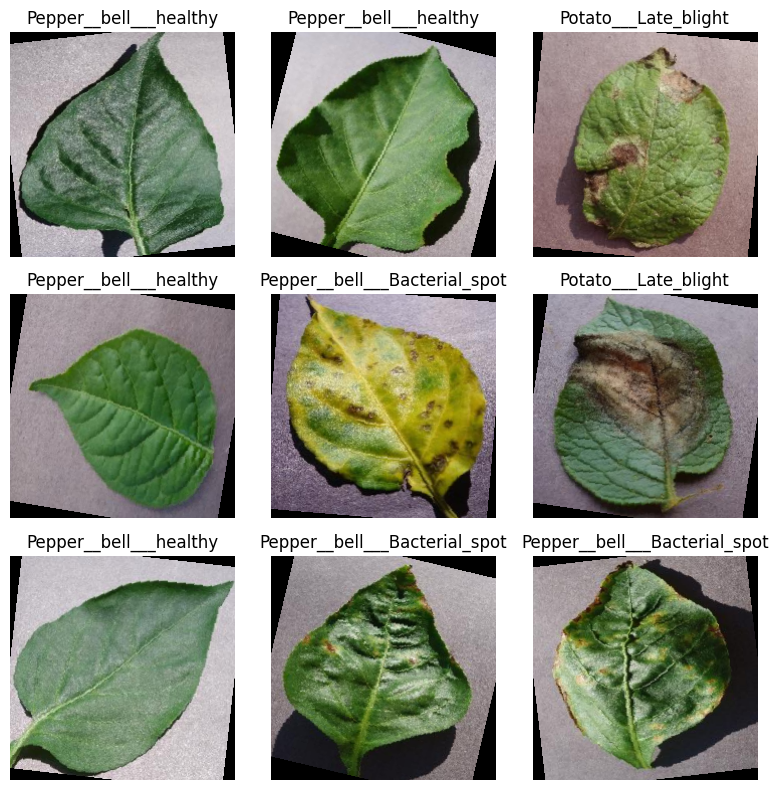

In [6]:
import matplotlib.pyplot as plt

classes = train_dataset.classes

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)  # convert tensor → image
    label = labels[i].item()

    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()


# CNN Model: RES-NET


In [7]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device: ", device)

using device:  cuda


In [8]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
print(model.fc)

Linear(in_features=2048, out_features=5, bias=True)


In [10]:
model = model.to(device)

In [11]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
print("images.shape:", images.shape)
print("labels.shape:", labels.shape)

images.shape: torch.Size([32, 3, 224, 224])
labels.shape: torch.Size([32])


In [12]:
outputs = model(images)
print("Output shape:", outputs.shape)

Output shape: torch.Size([32, 5])


In [13]:
_, preds = torch.max(outputs, dim=1)
print("Predictions:", preds[:10])
print("True labels:", labels[:10])

Predictions: tensor([2, 3, 1, 2, 2, 3, 1, 4, 3, 3], device='cuda:0')
True labels: tensor([3, 4, 0, 2, 3, 3, 2, 0, 2, 0], device='cuda:0')


In [14]:
# ===============================
# CNN MODEL: RESNET-50 TRAINING
# ===============================

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

model.train()

total_loss = 0
correct = 0
total = 0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    # 1. Forward pass
    outputs = model(images)

    # 2. Compute loss
    loss = criterion(outputs, labels)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backward pass
    loss.backward()

    # 5. Update weights
    optimizer.step()

    # tracking metrics
    total_loss += loss.item()

    _, preds = torch.max(outputs, dim=1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

train_loss = total_loss / len(train_loader)
train_acc = correct / total

print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_acc:.4f}")

Train Loss: 0.3111
Train Accuracy: 0.9278


In [15]:
# ===============================
# CNN MODEL: RESNET-50 Validation
# ===============================

model.eval()

val_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

val_loss /= len(val_loader)
val_acc = correct / total

print(f"Val Loss: {val_loss:.4f}")
print(f"Val Accuracy: {val_acc:.4f}")

Val Loss: 0.0249
Val Accuracy: 0.9935


In [ ]:
# ====================================================
# CNN MODEL: TRAIN and Validata over multiple epochs
# ====================================================

best_val_acc = 0

num_epochs = 5

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # TRAIN
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # SAVE ONLY IF IMPROVED
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/best_model.pth")
        print("🔥 New best model saved!")